# Load and Prepare Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()

Saving E0.xlsx to E0.xlsx


# Dataset Overview
| Feature     | Description             |
| ----------- | ----------------------- |
| Rows        | 349 matches             |
| Columns     | 132 variables           |
| Granularity | One row per match       |
| League      | English Premier League  |
| Season      | 2025/26                 |
| Data Types  | Numerical + categorical |


# Match Result Variables
| Column | Description          |
| ------ | -------------------- |
| `FTHG` | Full-Time Home Goals |
| `FTAG` | Full-Time Away Goals |
| `FTR`  | Full-Time Result     |
| `HTHG` | Half-Time Home Goals |
| `HTAG` | Half-Time Away Goals |
| `HTR`  | Half-Time Result     |


# Match Result Codes
| Code | Meaning  |
| ---- | -------- |
| `H`  | Home Win |
| `A`  | Away Win |
| `D`  | Draw     |


# Referee Information
| Column    | Description   |
| --------- | ------------- |
| `Referee` | Match referee |


# Shooting Statistics
| Column | Description          |
| ------ | -------------------- |
| `HS`   | Home shots           |
| `AS`   | Away shots           |
| `HST`  | Home shots on target |
| `AST`  | Away shots on target |


# Fouls & Discipline Statistics
| Column | Description          |
| ------ | -------------------- |
| `HF`   | Home fouls committed |
| `AF`   | Away fouls committed |
| `HY`   | Home yellow cards    |
| `AY`   | Away yellow cards    |
| `HR`   | Home red cards       |
| `AR`   | Away red cards       |


# Corner Statistics
| Column | Description  |
| ------ | ------------ |
| `HC`   | Home corners |
| `AC`   | Away corners |


# Bookmaker Odds
| Column  | Description          |
| ------- | -------------------- |
| `B365H` | Bet365 home win odds |
| `B365D` | Bet365 draw odds     |
| `B365A` | Bet365 away win odds |


# Multiple Bookmaker Markets
| Prefix | Bookmaker          |
| ------ | ------------------ |
| `B365` | Bet365             |
| `BFD`  | Betfair Sportsbook |
| `BMGM` | BetMGM             |
| `BV`   | BetVictor          |
| `BW`   | Betway             |
| `LB`   | Ladbrokes          |
| `PS`   | Pinnacle Sports    |
| `BFE`  | Betfair Exchange   |


In [3]:
df = pd.read_excel("E0.xlsx")


In [4]:
df.columns

Index(['Div', 'Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR',
       'HTHG', 'HTAG',
       ...
       'B365CAHH', 'B365CAHA', 'PCAHH', 'PCAHA', 'MaxCAHH', 'MaxCAHA',
       'AvgCAHH', 'AvgCAHA', 'BFECAHH', 'BFECAHA'],
      dtype='object', length=132)

In [5]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349 entries, 0 to 348
Columns: 132 entries, Div to BFECAHA
dtypes: datetime64[ns](1), float64(108), int64(16), object(7)
memory usage: 360.0+ KB


,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,2025-08-15,20:00:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,2025-08-16,12:30:00,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,2025-08-16,15:00:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,2025-08-16,15:00:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,2025-08-16,15:00:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


In [6]:
df.isnull().sum()

,0
Div,0
Date,0
Time,0
HomeTeam,0
AwayTeam,0
...,...
MaxCAHA,0
AvgCAHH,0
AvgCAHA,0
BFECAHH,21


In [7]:
df.duplicated().sum()

np.int64(0)

# Convert date column

In [8]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [ ]:
df.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,BFECAHH,BFECAHA
0,E0,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,...,2.03,1.78,2.07,1.85,2.03,1.88,1.94,1.76,2.14,1.86
1,E0,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,...,2.05,1.80,2.02,1.89,2.06,1.80,1.95,1.74,2.14,1.86
2,E0,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,...,1.83,2.03,1.93,2.00,1.84,2.03,1.80,1.96,1.91,2.08
3,E0,2025-08-16,15:00,Sunderland,West Ham,3,0,H,0,0,...,1.95,1.90,1.97,1.95,1.95,1.94,1.86,1.78,2.02,1.97
4,E0,2025-08-16,15:00,Tottenham,Burnley,3,0,H,1,0,...,1.98,1.88,1.99,1.93,1.98,1.91,1.88,1.83,2.07,1.92


# Business Question:

“Which Premier League teams most consistently outperform bookmaker expectations in the 2025/26 season?”

# Market Expectation
convert odds → probabilities:

In [9]:
df["home_prob"] = 1 / df["B365H"]
df["draw_prob"] = 1 / df["B365D"]
df["away_prob"] = 1 / df["B365A"]

In [10]:
total = df["home_prob"] + df["draw_prob"] + df["away_prob"]

df["home_prob"] /= total
df["draw_prob"] /= total
df["away_prob"] /= total

# Actual Outcome Encoding

In [11]:
df["actual_home_win"] = (df["FTR"] == "H").astype(int)
df["actual_draw"] = (df["FTR"] == "D").astype(int)
df["actual_away_win"] = (df["FTR"] == "A").astype(int)

# Create “Overperformance Score

In [12]:
df["home_overperf"] = df["actual_home_win"] - df["home_prob"]
df["away_overperf"] = df["actual_away_win"] - df["away_prob"]

# Aggregate by team

In [13]:
home = df.groupby("HomeTeam")["home_overperf"].mean()
away = df.groupby("AwayTeam")["away_overperf"].mean()

In [14]:
team_overperf = home + away
team_overperf = team_overperf.sort_values(ascending=False)

#Top overperforming teams:

In [15]:
team_overperf.head(10)

,0
HomeTeam,
Sunderland,0.181356
Aston Villa,0.165109
Fulham,0.161719
Everton,0.118838
Man United,0.114243
Brentford,0.090326
Arsenal,0.078726
Man City,0.035566
West Ham,-0.024339


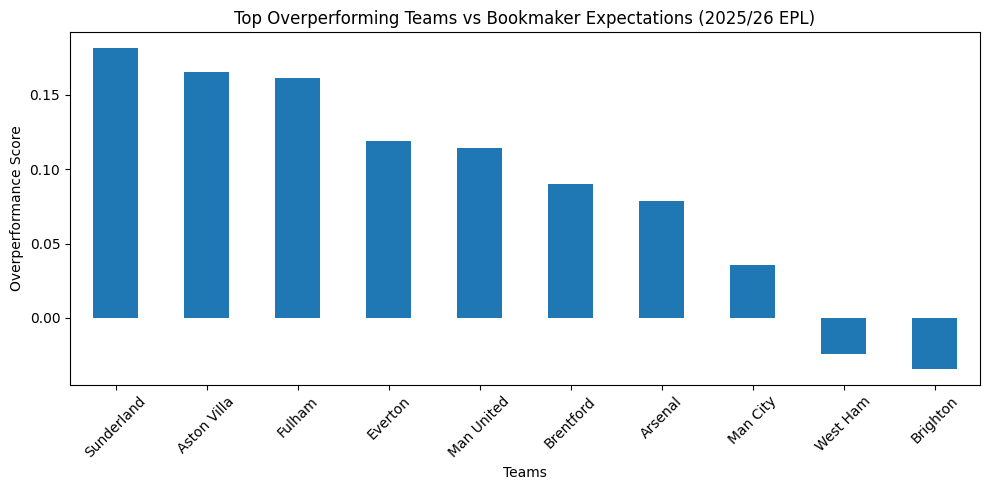

In [17]:
import matplotlib.pyplot as plt

top_over = team_overperf.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_over.plot(kind="bar")

plt.title("Top Overperforming Teams vs Bookmaker Expectations (2025/26 EPL)")
plt.xlabel("Teams")
plt.ylabel("Overperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Worst performing teams:

In [16]:
team_overperf.tail(10)

,0
HomeTeam,
Bournemouth,-0.034509
Nott'm Forest,-0.038031
Crystal Palace,-0.045845
Leeds,-0.059190
Liverpool,-0.117806
Newcastle,-0.125629
Burnley,-0.126276
Tottenham,-0.213493
Chelsea,-0.236213


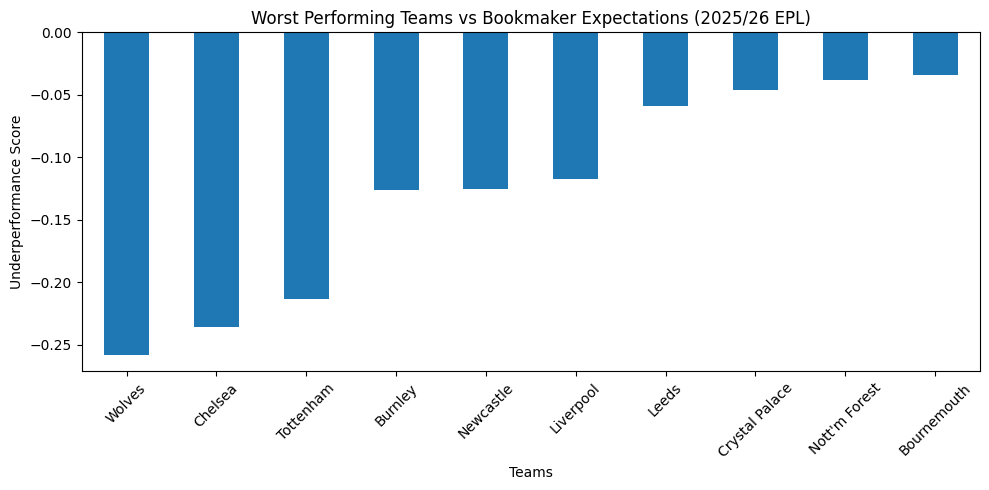

In [18]:
bottom_over = team_overperf.sort_values(ascending=True).head(10)

plt.figure(figsize=(10,5))
bottom_over.plot(kind="bar")

plt.title("Worst Performing Teams vs Bookmaker Expectations (2025/26 EPL)")
plt.xlabel("Teams")
plt.ylabel("Underperformance Score")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

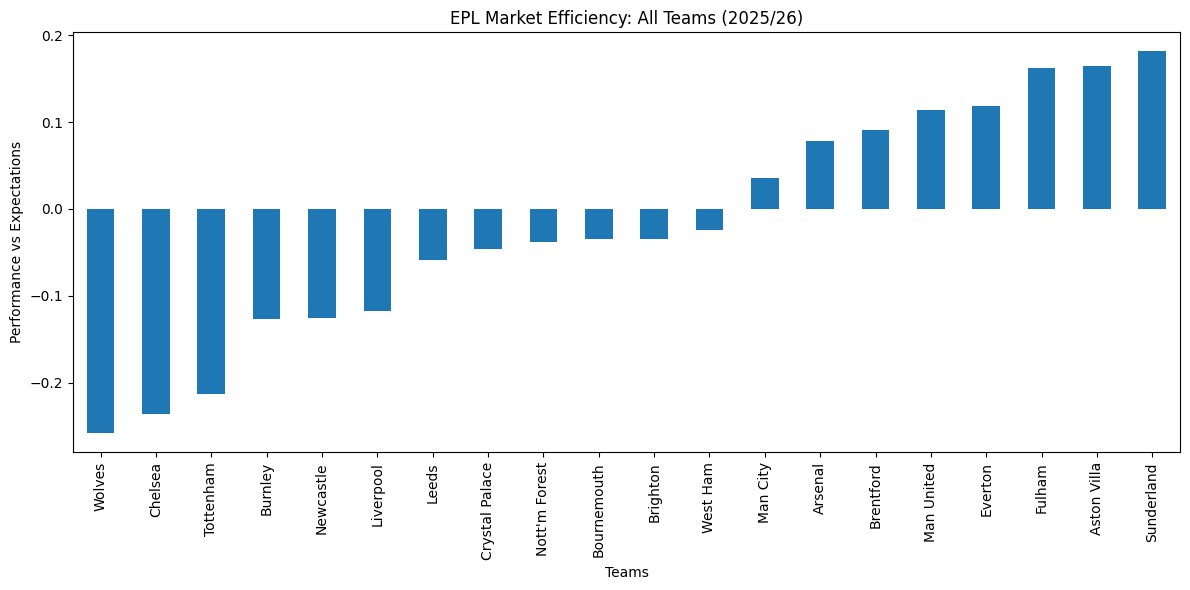

In [19]:
plt.figure(figsize=(12,6))
team_overperf.sort_values().plot(kind="bar")

plt.title("EPL Market Efficiency: All Teams (2025/26)")
plt.xlabel("Teams")
plt.ylabel("Performance vs Expectations")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

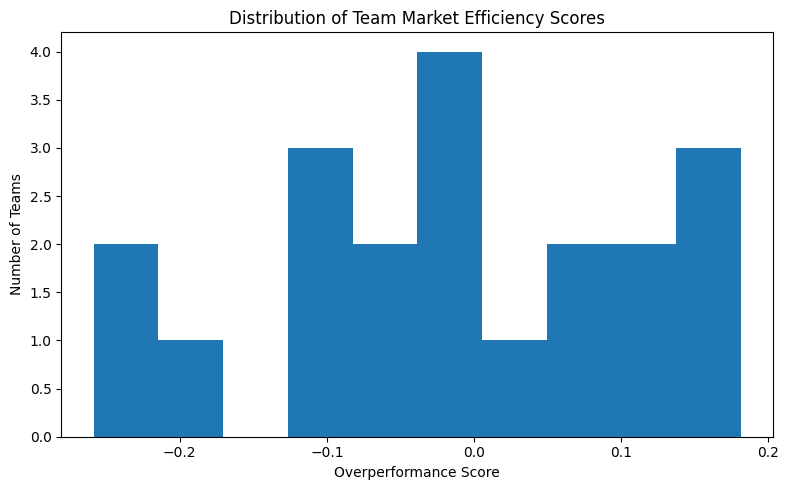

In [20]:
plt.figure(figsize=(8,5))

plt.hist(team_overperf, bins=10)

plt.title("Distribution of Team Market Efficiency Scores")
plt.xlabel("Overperformance Score")
plt.ylabel("Number of Teams")

plt.tight_layout()
plt.show()

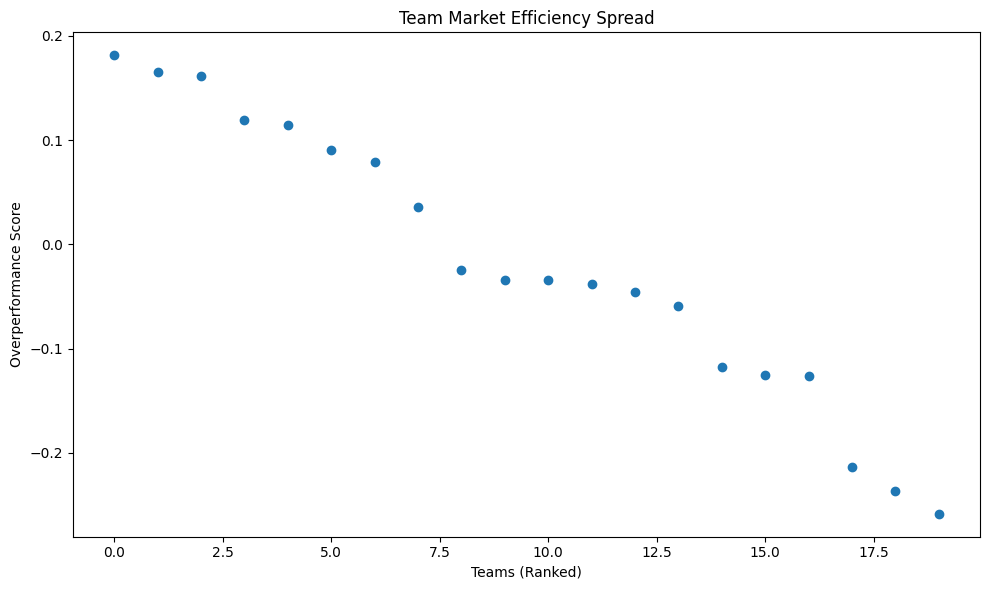

In [21]:
plt.figure(figsize=(10,6))

plt.scatter(
    range(len(team_overperf)),
    team_overperf.sort_values(ascending=False)
)

plt.title("Team Market Efficiency Spread")
plt.xlabel("Teams (Ranked)")
plt.ylabel("Overperformance Score")

plt.tight_layout()
plt.show()

In [34]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
from PIL import Image
from io import BytesIO

In [35]:
team_logos = {
    "Arsenal": "https://logo.clearbit.com/arsenal.com",
    "Chelsea": "https://logo.clearbit.com/chelseafc.com",
    "Liverpool": "https://logo.clearbit.com/liverpoolfc.com",
    "Man City": "https://logo.clearbit.com/mancity.com",
    "Man United": "https://logo.clearbit.com/manutd.com",
    "Tottenham": "https://logo.clearbit.com/tottenhamhotspur.com",
    "Newcastle": "https://logo.clearbit.com/nufc.co.uk",
    "Aston Villa": "https://logo.clearbit.com/avfc.co.uk",
    "Everton": "https://logo.clearbit.com/evertonfc.com",
    "West Ham": "https://logo.clearbit.com/whufc.com",
    "Brighton": "https://logo.clearbit.com/brightonandhovealbion.com",
    "Brentford": "https://logo.clearbit.com/brentfordfc.com",
    "Fulham": "https://logo.clearbit.com/fulhamfc.com",
    "Wolves": "https://logo.clearbit.com/wolves.co.uk",
    "Crystal Palace": "https://logo.clearbit.com/cpfc.co.uk",
    "Sunderland": "https://logo.clearbit.com/safc.com"
}

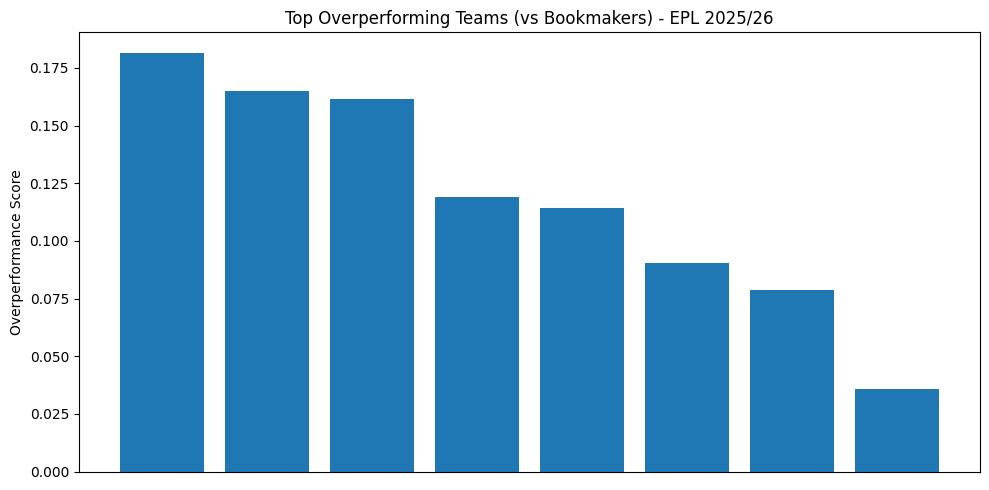

In [36]:
top_over = team_overperf.sort_values(ascending=False).head(8)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(top_over.index, top_over.values)

ax.set_title("Top Overperforming Teams (vs Bookmakers) - EPL 2025/26")
ax.set_ylabel("Overperformance Score")
ax.set_xticks([])  # remove text labels

# Add logos
for i, team in enumerate(top_over.index):
    try:
        url = team_logos[team]
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))

        ax.imshow(img, extent=(i-0.4, i+0.4, 0, top_over.values[i]), aspect='auto')
    except:
        pass

plt.tight_layout()
plt.show()

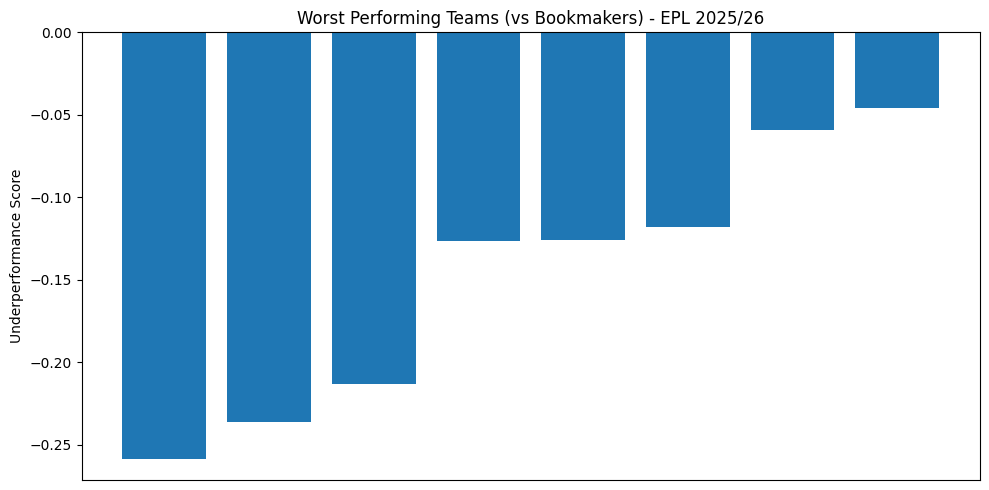

In [37]:
bottom_over = team_overperf.sort_values(ascending=True).head(8)

fig, ax = plt.subplots(figsize=(10,5))

bars = ax.bar(bottom_over.index, bottom_over.values)

ax.set_title("Worst Performing Teams (vs Bookmakers) - EPL 2025/26")
ax.set_ylabel("Underperformance Score")
ax.set_xticks([])

for i, team in enumerate(bottom_over.index):
    try:
        url = team_logos[team]
        response = requests.get(url)
        img = Image.open(BytesIO(response.content))

        ax.imshow(img, extent=(i-0.4, i+0.4, bottom_over.values[i], 0), aspect='auto')
    except:
        pass

plt.tight_layout()
plt.show()

In [40]:
df[["HomeTeam", "AwayTeam", "B365H", "B365D", "B365A"]].head(10)

,HomeTeam,AwayTeam,B365H,B365D,B365A
0,Liverpool,Bournemouth,1.30,6.00,8.50
1,Aston Villa,Newcastle,2.25,3.50,2.90
2,Brighton,Fulham,1.91,3.60,4.00
3,Sunderland,West Ham,3.25,3.40,2.25
4,Tottenham,Burnley,1.38,4.75,8.50
5,Wolves,Man City,6.25,4.75,1.45
6,Chelsea,Crystal Palace,1.62,4.33,4.50
7,Nott'm Forest,Brentford,2.20,3.30,3.50
8,Man United,Arsenal,3.60,3.60,1.95
9,Leeds,Everton,2.38,3.30,3.00


In [42]:
pip install plotly

In [43]:
import plotly.express as px

team_df = team_overperf.reset_index()
team_df.columns = ["Team", "Score"]

fig = px.bar(
    team_df.sort_values("Score"),
    x="Score",
    y="Team",
    orientation="h",
    text="Score",
    title="Team Performance vs Market Expectations"
)

st.plotly_chart(fig, use_container_width=True)

NameError: name 'st' is not defined